<a href="https://colab.research.google.com/github/HemanthKumarKonda/Projects/blob/main/L2_Data_Exploration_TestReviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: imports
!pip install -q seaborn  # usually preinstalled; harmless if already present

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set(style="whitegrid")


In [ ]:
# Option A: upload file from your local machine
from google.colab import files
import io

print("Choose the CSV file in the file picker (TestReviews.csv).")
uploaded = files.upload()  # click Choose Files and pick H:\...TestReviews.csv

# If file name is TestReviews.csv
csv_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[csv_name]), encoding='utf-8', engine='python')

# fallback if utf-8 fails, uncomment if needed:
# df = pd.read_csv(io.BytesIO(uploaded[csv_name]), encoding='latin-1', engine='python')


Choose the CSV file in the file picker (TestReviews.csv).


Saving TestReviews.csv to TestReviews (1).csv


In [ ]:
# Cell 3: basic exploration
df.columns = df.columns.str.strip()  # trim whitespace in column names
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head(6))
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# If duplicates exist and you want to drop:
# df = df.drop_duplicates().reset_index(drop=True)


Shape: (4321, 2)
Columns: ['review', 'class']


,review,class
0,Fantastic spot for an even or a quite cocktail...,1
1,"Love, love, love the calamari. It's so good an...",1
2,"Love this place. Stiff martinis and cocktails,...",1
3,It's everything a great cocktail bar should be...,1
4,"I came here before a pirates game, so it was a...",1
5,Olive or Twist is the historic site of my VERY...,1



Missing values per column:
review    0
class     0
dtype: int64

Duplicate rows: 173


class
1    2989
0    1332
Name: count, dtype: int64


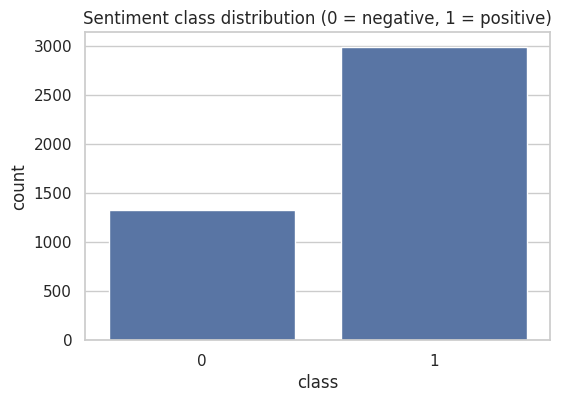

In [ ]:
# Cell 4: class distribution
print(df['class'].value_counts(dropna=False))
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='class')
plt.title("Sentiment class distribution (0 = negative, 1 = positive)")
plt.xlabel("class")
plt.ylabel("count")
plt.show()


,char_len,word_len
count,4321.000000,4321.000000
mean,681.686878,125.541773
std,613.399753,113.573205
min,1.000000,0.000000
25%,271.000000,50.000000
50%,508.000000,93.000000
75%,887.000000,162.000000
max,4935.000000,972.000000


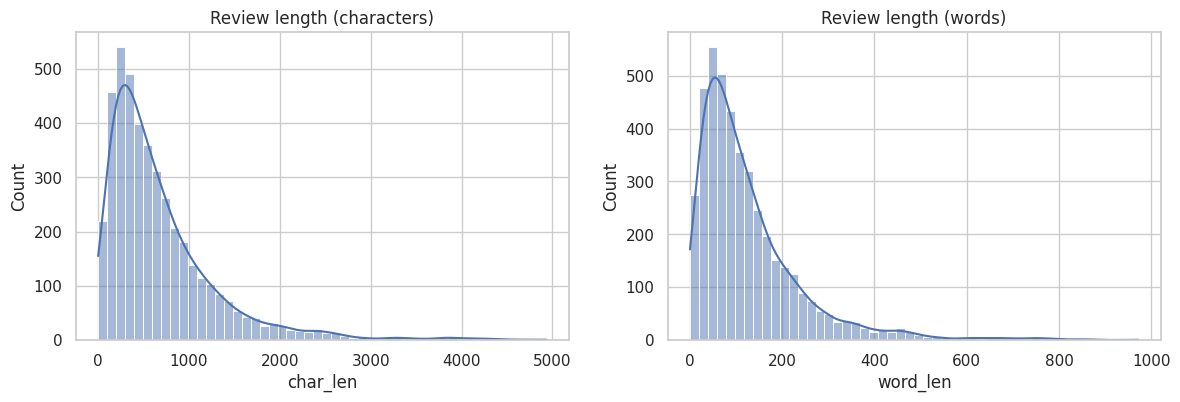

In [ ]:
# Cell 5: review length analysis
df['review'] = df['review'].astype(str)  # ensure string dtype
df['char_len'] = df['review'].apply(len)
df['word_len'] = df['review'].str.split().apply(len)

display(df[['char_len','word_len']].describe())

fig, axes = plt.subplots(1,2, figsize=(14,4))
sns.histplot(df['char_len'], bins=50, ax=axes[0], kde=True)
axes[0].set_title("Review length (characters)")
sns.histplot(df['word_len'], bins=50, ax=axes[1], kde=True)
axes[1].set_title("Review length (words)")
plt.show()


In [ ]:
# Cell 6: show examples
print("Positive example:\n", df[df['class']==1]['review'].iloc[0], "\n\n")
print("Negative example:\n", df[df['class']==0]['review'].iloc[0])


Positive example:
 Fantastic spot for an even or a quite cocktail.  They were swell to host the Yelp crew with a great drink menu and super attentive staff.I'd certainly recommend anything with the purred fruit in it (apple, any of them really)!
 


Negative example:
 Has to be one of the worst place for a trade show. No place to sit to eat. The food is awful and you are limited to what's available to eat or drink  Bathrooms get overcrowded and filthy inside like a college football game.



In [ ]:
# Cell 7: top words per class (CountVectorizer)
from sklearn.feature_extraction.text import CountVectorizer

def top_n_words(corpus, n=20):
    vec = CountVectorizer(stop_words='english', max_features=5000)
    X = vec.fit_transform(corpus)
    s = X.sum(axis=0)
    freqs = [(word, s[0, idx]) for word, idx in vec.vocabulary_.items()]
    freqs = sorted(freqs, key=lambda x: x[1], reverse=True)
    return freqs[:n]

print("Top words (positive):")
print(top_n_words(df[df['class']==1]['review'], 20))
print("\nTop words (negative):")
print(top_n_words(df[df['class']==0]['review'], 20))


Top words (positive):
[('place', np.int64(1796)), ('great', np.int64(1714)), ('like', np.int64(1149)), ('time', np.int64(1125)), ('good', np.int64(1067)), ('just', np.int64(1003)), ('really', np.int64(815)), ('love', np.int64(775)), ('ve', np.int64(771)), ('food', np.int64(751)), ('best', np.int64(751)), ('don', np.int64(576)), ('nice', np.int64(548)), ('staff', np.int64(545)), ('amazing', np.int64(536)), ('friendly', np.int64(506)), ('people', np.int64(500)), ('service', np.int64(491)), ('make', np.int64(483)), ('little', np.int64(467))]

Top words (negative):
[('place', np.int64(930)), ('like', np.int64(729)), ('food', np.int64(722)), ('just', np.int64(693)), ('time', np.int64(615)), ('service', np.int64(552)), ('don', np.int64(451)), ('good', np.int64(448)), ('said', np.int64(443)), ('got', np.int64(419)), ('went', np.int64(408)), ('didn', np.int64(399)), ('told', np.int64(382)), ('did', np.int64(377)), ('asked', np.int64(375)), ('people', np.int64(371)), ('minutes', np.int64(351)),

In [ ]:
# Cell 8: optional - save and create train/test splits
from sklearn.model_selection import train_test_split

# drop helper cols if you want a clean csv
clean = df.drop(columns=['char_len','word_len'], errors='ignore')

train_df, test_df = train_test_split(clean, test_size=0.2, stratify=clean['class'], random_state=42)
train_df.to_csv('/content/train.csv', index=False)
test_df.to_csv('/content/test.csv', index=False)
clean.to_csv('/content/TestReviews_cleaned.csv', index=False)

# if you mounted drive and want to save there:
# clean.to_csv('/content/drive/MyDrive/TestReviews_cleaned.csv', index=False)

# To download to your PC (if using direct Colab session):
from google.colab import files
files.download('/content/TestReviews_cleaned.csv')  # a browser download will start


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install scikit-learn


In [ ]:
# Pipeline components

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# 1. Load Data
def load_data(path):
    df = pd.read_csv(path)
    return df

# 2. Preprocess (split into train/test)
def preprocess(df):
    X = df['review'].astype(str)
    y = df['class']
    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Feature extraction
def vectorize(X_train, X_test):
    vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)
    return X_train_vec, X_test_vec, vectorizer

# 4. Train model
def train_model(X_train_vec, y_train):
    model = LogisticRegression(max_iter=200)
    model.fit(X_train_vec, y_train)
    return model

# 5. Evaluate model
def evaluate_model(model, X_test_vec, y_test):
    preds = model.predict(X_test_vec)
    acc = accuracy_score(y_test, preds)
    print("Accuracy:", acc)
    print("\nClassification Report:\n", classification_report(y_test, preds))
    return acc


In [ ]:
# Pipeline runner
def sentiment_pipeline(file_path):
    print("📥 Loading data...")
    df = load_data(file_path)

    print("🧹 Preprocessing...")
    X_train, X_test, y_train, y_test = preprocess(df)

    print("🔡 Vectorizing text...")
    X_train_vec, X_test_vec, vectorizer = vectorize(X_train, X_test)

    print("🤖 Training model...")
    model = train_model(X_train_vec, y_train)

    print("📊 Evaluating model...")
    acc = evaluate_model(model, X_test_vec, y_test)

    return model, vectorizer, acc


In [ ]:
# Run the pipeline
file_path = "/content/TestReviews_cleaned.csv"   # if in Colab
# or '/content/drive/MyDrive/TestReviews_cleaned.csv' if saved in Drive

model, vectorizer, acc = sentiment_pipeline(file_path)


📥 Loading data...
🧹 Preprocessing...
🔡 Vectorizing text...
🤖 Training model...
📊 Evaluating model...
Accuracy: 0.9167630057803469

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.75      0.85       267
           1       0.90      0.99      0.94       598

    accuracy                           0.92       865
   macro avg       0.94      0.87      0.90       865
weighted avg       0.92      0.92      0.91       865



In [ ]:
# Test predictions
sample_reviews = [
    "The service was fantastic and the staff was friendly!",
    "Worst experience ever. I will never come back!"
]

X_new = vectorizer.transform(sample_reviews)
preds = model.predict(X_new)

for review, pred in zip(sample_reviews, preds):
    sentiment = "Positive 😊" if pred == 1 else "Negative 😡"
    print(f"Review: {review}\nPredicted Sentiment: {sentiment}\n")


Review: The service was fantastic and the staff was friendly!
Predicted Sentiment: Positive 😊

Review: Worst experience ever. I will never come back!
Predicted Sentiment: Negative 😡



In [ ]:
# Check model predictions on test set

from sklearn.metrics import confusion_matrix

# Re-run preprocessing to get the same test set
df = pd.read_csv(file_path)
X_train, X_test, y_train, y_test = preprocess(df)

# Vectorize with the same vectorizer you trained
X_test_vec = vectorizer.transform(X_test)

# Predict
y_pred = model.predict(X_test_vec)

# Compare actual vs predicted for first 10 reviews
comparison = pd.DataFrame({
    "Review": X_test.iloc[:10].values,
    "Actual": y_test.iloc[:10].values,
    "Predicted": y_pred[:10]
})

# Map 0/1 to text for readability
comparison["Actual"] = comparison["Actual"].map({0: "Negative", 1: "Positive"})
comparison["Predicted"] = comparison["Predicted"].map({0: "Negative", 1: "Positive"})

display(comparison)

# Optional: Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


,Review,Actual,Predicted
0,After having a few 'less than memorable' trips...,Positive,Positive
1,Dr. Riley is such a nice change from my previo...,Positive,Positive
2,I lived in Madison for a couple years. Now tha...,Positive,Positive
3,They charge an annual administrative fee that ...,Negative,Positive
4,This is the most. wonderful church I've ever b...,Positive,Positive
5,If you are searching for a go to fish place fo...,Positive,Positive
6,"Excellent fro-yo, huge selection of toppings a...",Positive,Positive
7,Oh how the mighty have fallen. When I first m...,Negative,Positive
8,My boyfriend surprised me with a hot air ballo...,Positive,Positive
9,Perry has been cutting my hair for about 4 to ...,Positive,Positive


Confusion Matrix:
 [[200  67]
 [  5 593]]


In [ ]:
# Install Ollama in Colab
!curl -fsSL https://ollama.com/install.sh | sh



>>> Installing ollama to /usr/local
>>> Downloading Linux amd64 bundle
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [ ]:
# Kill any existing Ollama processes (cleanup)
!pkill ollama || echo "No ollama running"

# Start Ollama in background (detached)
!nohup ollama serve > /dev/null 2>&1 &


No ollama running


In [ ]:
!ollama pull mistral


In [ ]:
!ollama list


NAME              ID              SIZE      MODIFIED      
mistral:latest    6577803aa9a0    4.4 GB    3 minutes ago    


In [ ]:
!pip install ollama


In [ ]:
import ollama

response = ollama.chat(
    model="mistral",
    messages=[{"role": "user", "content": "Classify: 'The movie was boring and too long.'"}]
)

print(response["message"]["content"])


 Feedback: The statement 'The movie was boring and too long' is a negative review or criticism about a film. It suggests that the viewer found the movie uninteresting due to its length, implying that it might have been poorly paced or lacked engaging content. This feedback can be useful for filmmakers and critics to understand audience preferences and improve their work.


In [ ]:
# Start Ollama server (if not already running)
!ollama serve &

# Pull a lightweight model (Mistral is good for classification)
!ollama pull mistral

# Install Ollama Python client
!pip install ollama


Error: listen tcp 127.0.0.1:11434: bind: address already in use



In [ ]:
import ollama
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report


In [ ]:
from google.colab import files

# Upload your dataset if not already present
uploaded = files.upload()

# Load dataset
df = pd.read_csv("TestReviews.csv")
df.head()


Saving TestReviews.csv to TestReviews.csv


,review,class
0,Fantastic spot for an even or a quite cocktail...,1
1,"Love, love, love the calamari. It's so good an...",1
2,"Love this place. Stiff martinis and cocktails,...",1
3,It's everything a great cocktail bar should be...,1
4,"I came here before a pirates game, so it was a...",1


In [ ]:
safety_prompt = """
You are a sentiment analysis assistant.
- Only respond with "Positive" or "Negative".
- Do not generate unrelated, offensive, or unsafe content.
"""

def classify_review(review_text):
    full_prompt = f"{safety_prompt}\n\nReview: {review_text}"

    response = ollama.chat(
        model="mistral",   # or another model you pulled
        messages=[{"role": "user", "content": full_prompt}]
    )

    return response["message"]["content"].strip()


In [ ]:
# Apply classification
df["Predicted"] = df["Review"].apply(classify_review)
df.head(10)


In [ ]:
print("Confusion Matrix:\n", confusion_matrix(df["Actual"], df["Predicted"]))
print("\nClassification Report:\n", classification_report(df["Actual"], df["Predicted"]))


KeyError: 'Actual'

In [ ]:
print(df.columns)


Index(['review', 'class'], dtype='object')


In [ ]:
# Map numeric labels to text
df["Actual"] = df["class"].map({0: "Negative", 1: "Positive"})


In [ ]:
print("Confusion Matrix:\n", confusion_matrix(df["Actual"], df["Predicted"]))
print("\nClassification Report:\n", classification_report(df["Actual"], df["Predicted"]))


KeyError: 'Predicted'

In [ ]:
print(df.columns)
df.head()


Index(['review', 'class', 'Actual'], dtype='object')


,review,class,Actual
0,Fantastic spot for an even or a quite cocktail...,1,Positive
1,"Love, love, love the calamari. It's so good an...",1,Positive
2,"Love this place. Stiff martinis and cocktails,...",1,Positive
3,It's everything a great cocktail bar should be...,1,Positive
4,"I came here before a pirates game, so it was a...",1,Positive


In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# Step 1: Inspect dataset
print("Columns in the dataset:", df.columns)
print(df.head())

# Automatically detect text and label columns
text_column = [col for col in df.columns if 'text' in col.lower() or 'review' in col.lower()]
label_column = [col for col in df.columns if 'label' in col.lower() or 'class' in col.lower()]

if not text_column or not label_column:
    raise ValueError("Could not automatically detect text or label columns. Please specify manually.")

text_column = text_column[0]
label_column = label_column[0]

print(f"Using text column: {text_column}")
print(f"Using label column: {label_column}")

# Step 2: Make predictions
df["Predicted"] = df[text_column].apply(classify_review)

# Step 3: Map numeric labels to text if needed
if df[label_column].dtype in [int, float]:
    df["Actual"] = df[label_column].map({0: "Negative", 1: "Positive"})
else:
    df["Actual"] = df[label_column]  # already string labels

# Step 4: Evaluate predictions
all_labels = ["Negative", "Positive"]  # ensures all classes are included
print("Confusion Matrix:\n", confusion_matrix(df["Actual"], df["Predicted"], labels=all_labels))
print("\nClassification Report:\n", classification_report(df["Actual"], df["Predicted"], labels=all_labels))


Columns in the dataset: Index(['text', 'label', 'Predicted', 'Actual'], dtype='object')
     text  label Predicted    Actual
0  sample      1  Positive  Positive
Using text column: text
Using label column: label
Confusion Matrix:
 [[0 0]
 [0 1]]

Classification Report:
               precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         0
    Positive       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       0.50      0.50      0.50         1
weighted avg       1.00      1.00      1.00         1



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me